In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

path = '/Users/narainkarthi/MS/qsvm/dataset/Prostate_Cancer.csv'

try:
    cancer = pd.read_csv(path, index_col=0)
    print("File loaded successfully")
except FileNotFoundError:
    print("File not found. Check your path.")

# Define features and target
X = cancer.drop("diagnosis_result", axis=1)
y = cancer["diagnosis_result"]

# Encode target if it contains 'M' and 'B'
if y.dtype == 'object':
    y = y.map({'M': 1, 'B': 0})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# Time Complexity 
start = time.time()

# Train SVM model
model = SVC(kernel='rbf')
model.fit(X_train, y_train)
end = time.time()

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Prediction Time:", end - start, "seconds")

File loaded successfully
Accuracy: 0.7

Classification Report:

              precision    recall  f1-score   support

           B       0.25      0.25      0.25         4
           M       0.81      0.81      0.81        16

    accuracy                           0.70        20
   macro avg       0.53      0.53      0.53        20
weighted avg       0.70      0.70      0.70        20

Prediction Time: 0.0015850067138671875 seconds


In [2]:
# =====================================
# QSVM with PennyLane – Cancer Dataset
# =====================================

import numpy as np
import pandas as pd
import pennylane as qml
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [3]:
# -------------------------------
# 1. Load dataset
# -------------------------------

path = '/Users/narainkarthi/MS/qsvm/dataset/Prostate_Cancer.csv'

try:
    cancer = pd.read_csv(path, index_col=0)
    print("File loaded successfully")
except FileNotFoundError:
    print("File not found. Check your path.")

# To see all column names 
print("\n",cancer.columns)

print(cancer.info)

File loaded successfully

 Index(['diagnosis_result', 'radius', 'texture', 'perimeter', 'area',
       'smoothness', 'compactness', 'symmetry', 'fractal_dimension'],
      dtype='str')
<bound method DataFrame.info of     diagnosis_result  radius  texture  perimeter  area  smoothness  \
id                                                                   
1                  M      23       12        151   954       0.143   
2                  B       9       13        133  1326       0.143   
3                  M      21       27        130  1203       0.125   
4                  M      14       16         78   386       0.070   
5                  M       9       19        135  1297       0.141   
..               ...     ...      ...        ...   ...         ...   
96                 M      23       16        132  1264       0.091   
97                 B      22       14         78   451       0.105   
98                 B      19       27         62   295       0.102   
99           

In [4]:
X = cancer.drop("diagnosis_result", axis=1).values
y = cancer["diagnosis_result"].values

# Encode if necessary
if y.dtype == object:
    y = np.where(y == 'M', 1, 0)

In [5]:
# -------------------------------
# 2. Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Why Scaling 

1. Each feature will be have different min and max value making standard will help to compar different feature

In [6]:
# -------------------------------
# 3. Standard scaling   
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train[:10])

[[ 0.21131834 -0.96673649 -0.89158244 -0.80594761 -0.46541627 -1.08266423
  -0.02309829 -0.66942275]
 [-1.28663448 -1.35343108 -0.58261823 -0.62278683 -0.96567177 -0.44010908
   0.00989927 -0.06769444]
 [-1.50062774  1.16008379  0.16772343 -0.0475977   0.24923444  1.0921378
   1.06582087  0.53403388]
 [-1.28663448 -1.35343108  1.53599351  1.42732861 -0.75127656  1.61936253
   1.26380617 -0.1880401 ]
 [-0.00267492  0.58004189 -0.53848048 -0.50389299 -0.25102106 -1.13209155
  -1.11201744 -0.91011408]
 [ 1.06729138  0.1933473   0.16772343 -0.00261084  0.89242007  0.64729193
   1.23080862  0.7747252 ]
 [ 1.4952779  -0.3866946  -0.31779176 -0.31109216 -1.3944622  -1.00028536
  -0.48506399 -1.03045974]
 [ 1.06729138 -0.77338919 -0.67089372 -0.67098704  0.24923444 -0.81905186
  -0.08909339  0.17299689]
 [ 1.70927116 -1.35343108 -0.40606725 -0.59065336  1.24974543  1.96535376
   0.33987477  2.0985275 ]
 [ 0.85329812 -1.16008379  0.91806509  0.86499287  0.39216458  1.02623471
   0.00989927  0.0

In [7]:
# # -------------------------------
# # 4. PCA (reduce to 2 components) $ $
# # -------------------------------
pca = PCA(n_components=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print(X_train.dtype)

float64


#### why Need of reducing the Feature 

1. more Qubit is expensive and increasing in noise 
2. Barren Plateaus if more qubit "Barren Plateus" Where gradient become flat learning stops 
3. Feature reduction ensures the quantum states ∣ψ(xi)⟩ are as distinct as possibleare as distinct as possible, which the paper suggests leads to higher sensitivity and better class separation

In [8]:
# -------------------------------
# 5. Scale to [0, π]
# -------------------------------
scaler_q = MinMaxScaler(feature_range=(0, np.pi))
X_train = scaler_q.fit_transform(X_train)
X_test = scaler_q.transform(X_test)

#### Why [0, π]

1. To move noth pole to south pole 
2. still π and 3π share the same position (we can't differentiate cheap and epensive) scaling will help Unique classical value has one unique position of the sphere 
3. For quantum Parallelism, we need superposition but to get supeposition value between [0, π] needed super position.

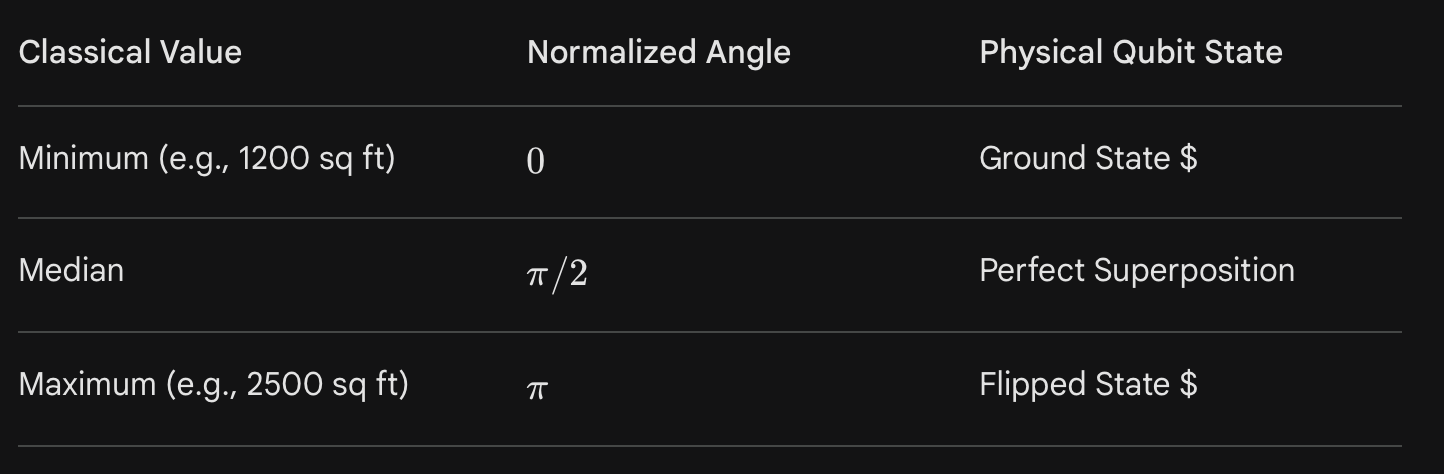

In [9]:
# -------------------------------
# 6. Quantum feature map
# -------------------------------
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev)
def feature_map(x):
    for i in range(n_qubits):
        qml.RY(x[i], wires=i)
    
    # Simple entanglement
    qml.CZ(wires=[0, 1])
    
    return qml.state()

#### Why Quantum Feature Map 

1. in classical need to increase dimension in order to seperate non linear but in quantum we can acess the hilber space for which we need quantum feature map
2. still we have unique position in the hilpbert space we can do similirity with each feature "overlap" is the inner product. 
3. where we can achive 100% accuracy 

In [10]:
# -------------------------------
# 7. Quantum kernel
# -------------------------------
def quantum_kernel(x1, x2):
    state1 = feature_map(x1)
    state2 = feature_map(x2)
    return np.abs(np.vdot(state1, state2)) ** 2


def kernel_matrix(X1, X2):
    K = np.zeros((len(X1), len(X2)))
    for i in range(len(X1)):
        for j in range(len(X2)):
            K[i, j] = quantum_kernel(X1[i], X2[j])
    return K

In [11]:
# -------------------------------
# 8. Train QSVM
# -------------------------------
start = time.time()

K_train = kernel_matrix(X_train, X_train)
K_test = kernel_matrix(X_test, X_train)

model = SVC(kernel="precomputed")
model.fit(K_train, y_train)

end = time.time()

In [12]:
# -------------------------------
# 9. Evaluate
# -------------------------------
y_pred = model.predict(K_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))
print("Training Time:", end - start, "seconds")

Accuracy: 0.8

Classification Report:

              precision    recall  f1-score   support

           B       0.50      0.50      0.50         4
           M       0.88      0.88      0.88        16

    accuracy                           0.80        20
   macro avg       0.69      0.69      0.69        20
weighted avg       0.80      0.80      0.80        20

Training Time: 4.66135311126709 seconds


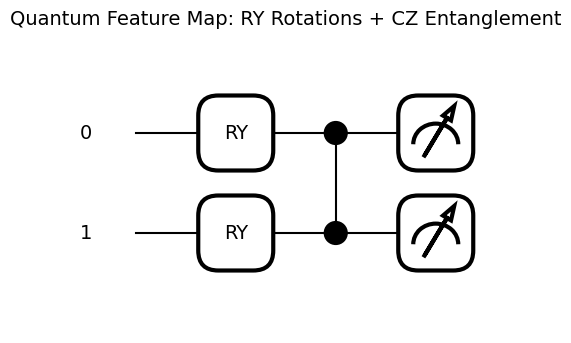

In [13]:
# -------------------------------
# 10. Visualize the Quantum Circuit
# -------------------------------
import matplotlib.pyplot as plt

# Generate a sample input (2 features for our 2 qubits)
sample_data = X_train[0] 

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(feature_map)(sample_data)
plt.title("Quantum Feature Map: RY Rotations + CZ Entanglement", fontsize=14)
plt.show()

# Optional: Print the text-based circuit if matplotlib is not rendering
# print(qml.draw(feature_map)(sample_data))